<a href="https://colab.research.google.com/github/Linejesus/Computacao_Grafica/blob/main/lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
!apt-get update -qq
!apt-get install -y xvfb freeglut3-dev -qq
!pip install -q PyOpenGL pyvirtualdisplay imageio

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [23]:
import numpy as np
import imageio
from PIL import Image
from IPython.display import display, Image as IPImage
from pyvirtualdisplay import Display

import OpenGL.GL as gl
import OpenGL.GLUT as glut
from OpenGL.GLU import gluPerspective
import math

In [24]:
WIDTH = 640
HEIGHT = 480

virtual_display = Display(visible=0, size=(640,480))
virtual_display.start()

In [25]:
glut.glutInit()
glut.glutInitDisplayMode(glut.GLUT_RGBA | glut.GLUT_SINGLE | glut.GLUT_DEPTH)
glut.glutInitWindowSize(640, 480)
glut.glutCreateWindow("Laboratorio 2")

3

In [26]:
def show_image():
  gl.glFlush()
  img_buf = gl.glReadPixels(0, 0, 640, 480, gl.GL_RGB, gl.GL_UNSIGNED_BYTE)
  img = np.frombuffer(img_buf, np.uint8).reshape(480, 640, 3)[::-1]
  display(Image.fromarray(img))


def show_animation(frames, fps=30):
  filename = 'animacao.gif'
  imageio.mimsave(filename, frames, fps=fps)
  display(IPImage(open(filename,'rb').read()))

In [27]:
vertices_cubo = ((1, -1, -1), (1, 1, -1), (-1, 1, -1),
                 (-1, -1, -1), (1, -1, 1), (1, 1, 1),
                 (-1, -1, 1), (-1, 1, 1))


faces_cubo = ((0, 1, 2, 3), (3, 2, 7, 6), (6, 7, 5, 4),
              (4, 5, 1, 0), (1, 5, 7, 2), (4, 0, 3, 6))

cores_cubo = ((1, 0, 0), (0, 1, 0), (0, 0, 1),
              (1, 1, 0), (1, 0, 1), (0, 1, 1))

def desenha_cubo():
    gl.glBegin(gl.GL_QUADS)
    for i, face in enumerate(faces_cubo):
        gl.glColor3f(*cores_cubo[i])
        for vertice in face:
            gl.glVertex3f(*vertices_cubo[vertice])
    gl.glEnd()

In [28]:
FPS = 30
DURATION = 5
TOTAL_FRAMES = FPS * DURATION

frames_cubo = []

gl.glViewport(0, 0, 640, 480)

gl.glEnable(gl.GL_DEPTH_TEST)
gl.glMatrixMode(gl.GL_PROJECTION)
gl.glLoadIdentity()
gluPerspective(45, (640 / 480), 0.1, 50.0)

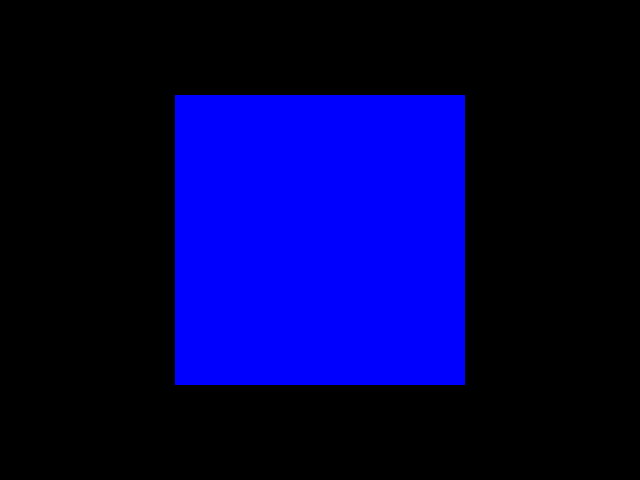

In [29]:
gl.glMatrixMode(gl.GL_MODELVIEW)

for i in range(TOTAL_FRAMES):
  gl.glClear(gl.GL_COLOR_BUFFER_BIT | gl.GL_DEPTH_BUFFER_BIT)
  gl.glLoadIdentity()

  gl.glTranslatef(0.0, 0.0, -5.0)

  angulo = i * 2.0
  gl.glRotatef(angulo, 0.0, 1.0, 0.0)

  desenha_cubo()

  gl.glFlush()

  img_buf = gl.glReadPixels(0, 0, WIDTH, HEIGHT, gl.GL_RGB, gl.GL_UNSIGNED_BYTE)
  img = np.frombuffer(img_buf, np.uint8).reshape(HEIGHT, WIDTH, 3)[::-1]
  frames_cubo.append(img)

show_animation(frames_cubo)

In [30]:
# Qualquer tipo de entrada, nós recebemos pelo callback

In [31]:
import ipywidgets as widgets
from ipywidgets import interact
from OpenGL.GLU import gluPerspective

def interatividade(pos_x, pos_y, pos_z, rot_x, rot_y, rot_z, escala):
  gl.glEnable(gl.GL_DEPTH_TEST)
  gl.glClearColor(0.2, 0.2, 0.25, 1.0)
  gl.glClear(gl.GL_COLOR_BUFFER_BIT | gl.GL_DEPTH_BUFFER_BIT)

  gl.glMatrixMode(gl.GL_PROJECTION)
  gl.glLoadIdentity()
  gluPerspective(45, (640 / 480), 0.1, 50.0)

  gl.glMatrixMode(gl.GL_MODELVIEW)
  gl.glLoadIdentity()
  gl.glTranslatef(0.0, 0.0, -5.0)

  gl.glTranslatef(pos_x, pos_y, pos_z)
  gl.glRotatef(rot_x, 1, 0, 0)
  gl.glRotatef(rot_x, 0, 1, 0)
  gl.glRotatef(rot_x, 0, 0, 1)
  gl.glScalef(escala, escala, escala)

  desenha_cubo()

  show_image()

In [32]:
interact(interatividade,
         pos_x = widgets.FloatSlider(min=-2.0, max=2.0, step=0.1, value=0.0, description='Trans X'),
         pos_y = widgets.FloatSlider(min=-2.0, max=2.0, step=0.1, value=0.0, description='Trans Y'),
         pos_z = widgets.FloatSlider(min=-2.0, max=2.0, step=0.1, value=0.0, description='Trans Z'),
         rot_x = widgets.FloatSlider(min=-0.0, max=360.0, step=5.0, value=15.0, description='Rot X (Pitch)'),
         rot_y = widgets.FloatSlider(min=-0.0, max=360.0, step=5.0, value=45.0, description='Rot Y (Yaw)'),
         rot_z = widgets.FloatSlider(min=-0.0, max=360.0, step=5.0, value=0.0, description='Rot Z (Roll)'),
         escala = widgets.FloatSlider(min=0.1, max=3.0, step=0.1, value=1.0, description='Escala'))

interactive(children=(FloatSlider(value=0.0, description='Trans X', max=2.0, min=-2.0), FloatSlider(value=0.0,…

<function __main__.interatividade(pos_x, pos_y, pos_z, rot_x, rot_y, rot_z, escala)>